Task 1: Data Cleaning and
Preprocessing

Load the dataset using pandas.
Identify and handle missing values (e.g., imputation or
removal).
Remove duplicate rows and standardize inconsistent
data formats (e.g., date formats, categorical variables).

Objectives:

Tools: Python, pandas.

# **Level 1(Basic)**

In [ ]:
import pandas as pd

# Load the dataset
try:
    df = pd.read_csv('/content/2) Stock Prices Data Set.csv')
except FileNotFoundError:
    print("Error: Dataset file not found. Please replace 'your_dataset.csv' with the correct file path.")
    # Exit or handle the error appropriately
    exit()


# Identify and handle missing values (example: drop rows with missing 'volume' or 'date')
df.dropna(subset=['volume', 'date'], inplace=True)

# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Standardize date formats (convert 'date' column to datetime objects)
df['date'] = pd.to_datetime(df['date'])

# Display the cleaned DataFrame (optional)
display(df.head())

,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391


Task 2: Exploratory Data Analysis
(EDA)

Calculate summary statistics (mean, median, mode,
standard deviation).
Visualize data distributions using histograms, boxplots,
and scatter plots.
Find correlations between numerical features.

Tools: Python, pandas, matplotlib,
seaborn.

,open,high,low,close,volume
count,497461.000000,497464.000000,497464.000000,497472.000000,4.974720e+05
mean,86.352275,87.132562,85.552467,86.369082,4.253611e+06
std,101.471228,102.312062,100.570957,101.472407,8.232139e+06
min,1.620000,1.690000,1.500000,1.590000,0.000000e+00
25%,41.690000,42.090000,41.280000,41.703750,1.080166e+06
50%,64.970000,65.560000,64.353700,64.980000,2.084896e+06
75%,98.410000,99.230000,97.580000,98.420000,4.271928e+06
max,2044.000000,2067.990000,2035.110000,2049.000000,6.182376e+08


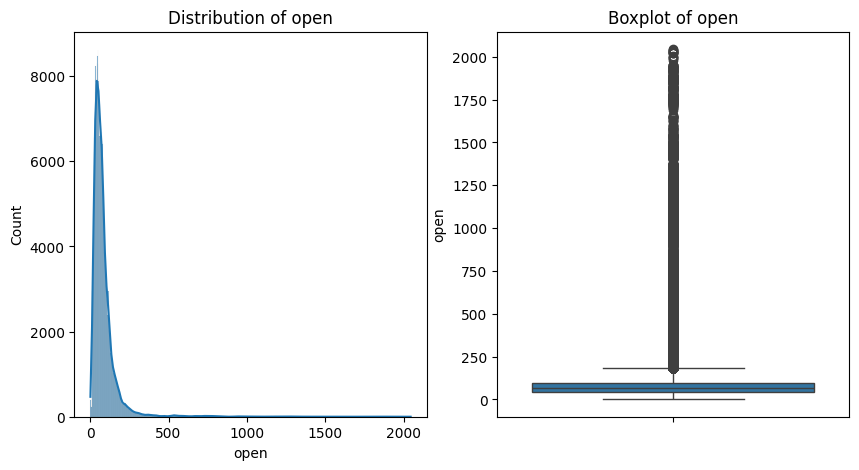

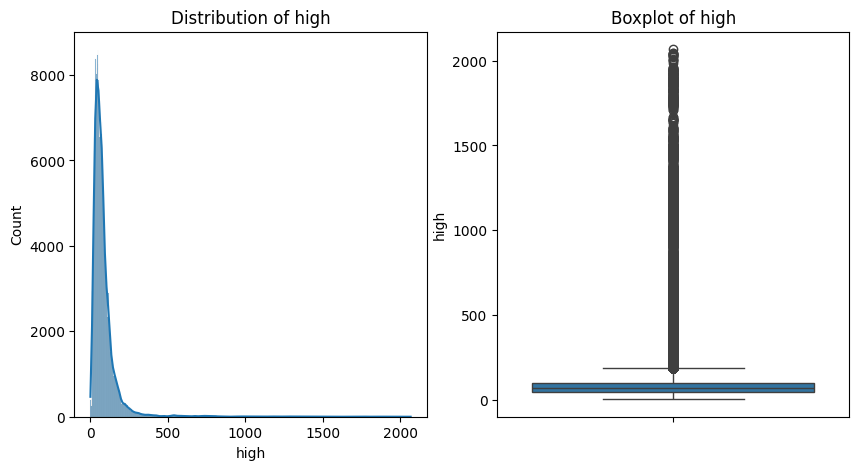

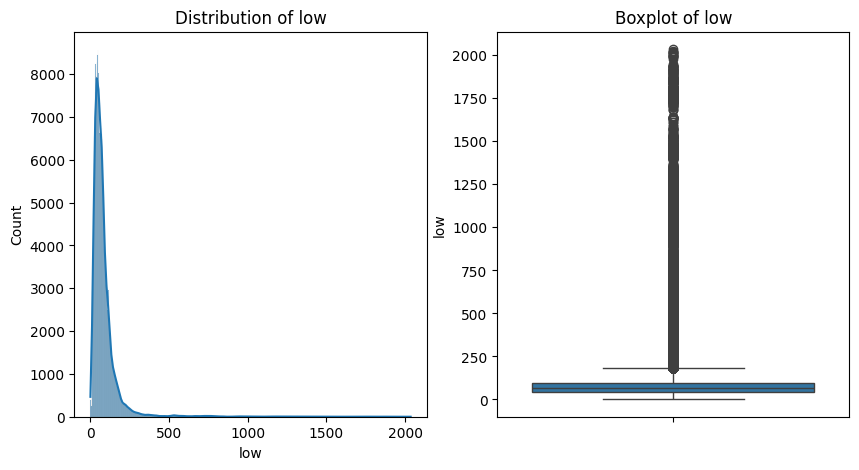

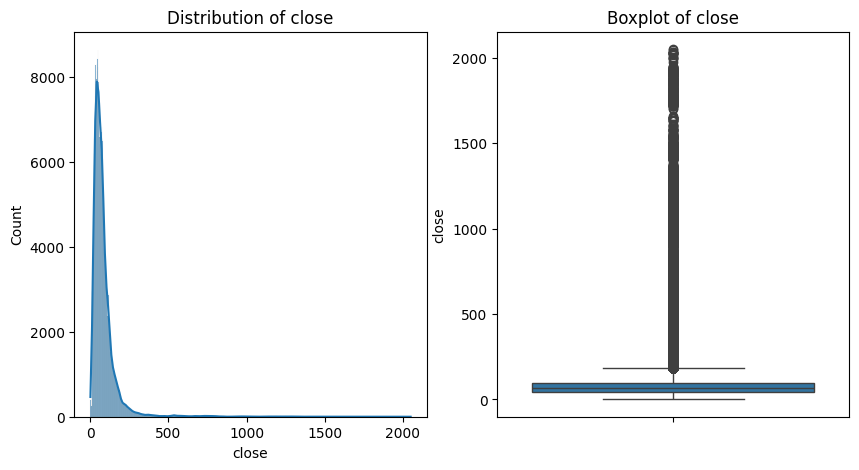

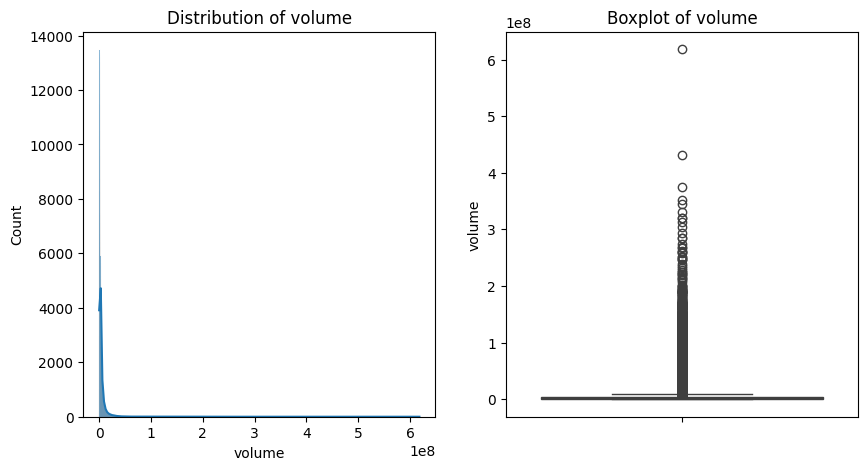

,open,high,low,close,volume
open,1.000000,0.999941,0.999928,0.999876,-0.148724
high,0.999941,1.000000,0.999905,0.999938,-0.148344
low,0.999928,0.999905,1.000000,0.999941,-0.149284
close,0.999876,0.999938,0.999941,1.000000,-0.148839
volume,-0.148724,-0.148344,-0.149284,-0.148839,1.000000


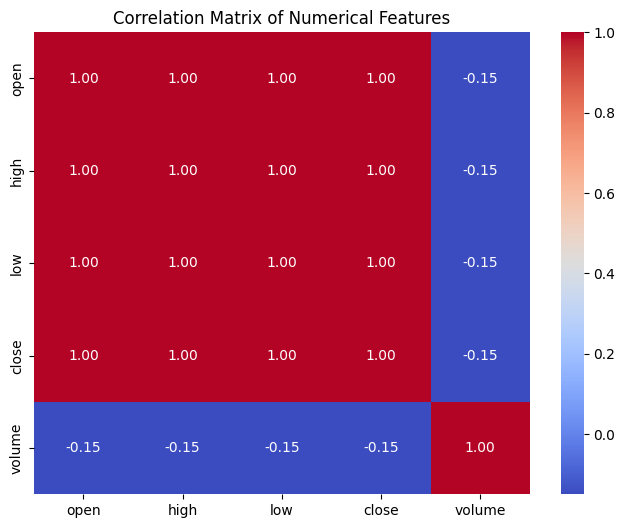

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load the data
df = pd.read_csv('/content/2) Stock Prices Data Set.csv')

# Calculate summary statistics
display(df.describe())

# Visualize data distributions using histograms and boxplots
numerical_cols = ['open', 'high', 'low', 'close', 'volume']
for col in numerical_cols:
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')

    plt.subplot(1, 2, 2)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

# Find correlations between numerical features
correlation_matrix = df[numerical_cols].corr()
display(correlation_matrix)

# Visualize correlations using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

Task 3: Basic Data Visualization

Create bar plots, line charts, and scatter plots.
Customize plot labels, titles, and legends.
Export plots as images for reports.

Objectives:

Tools: Python, matplotlib, seaborn.

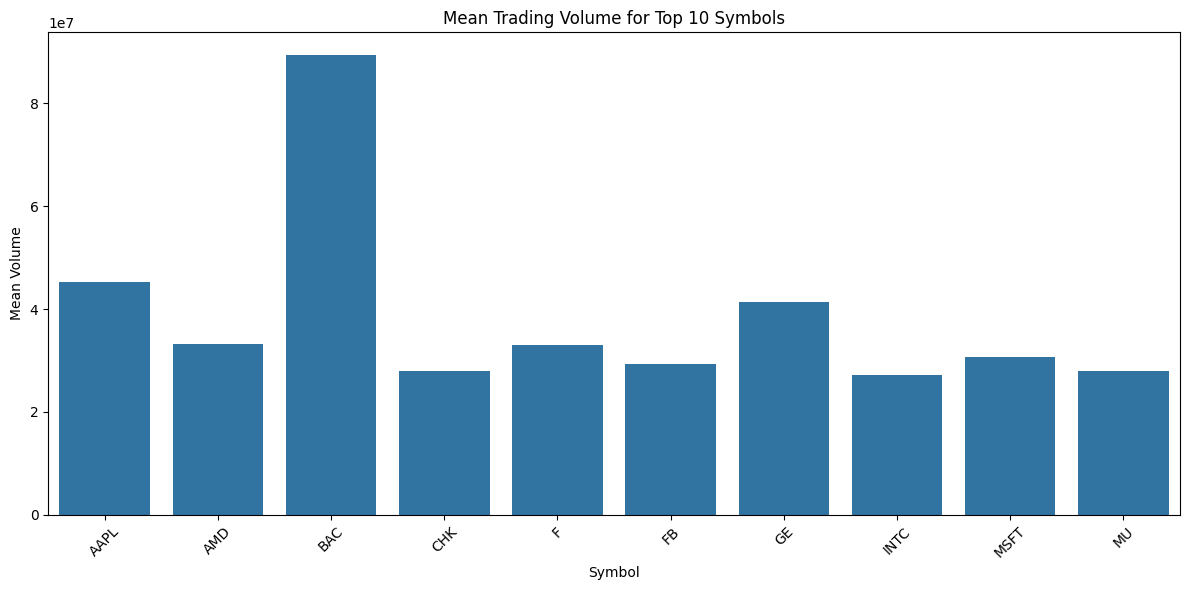

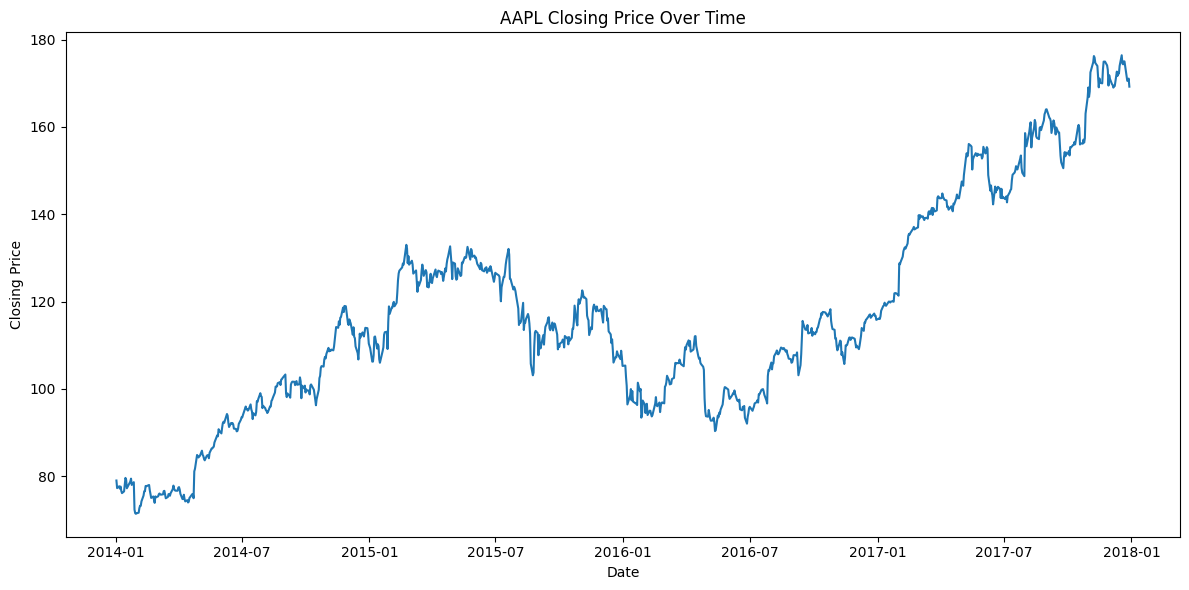

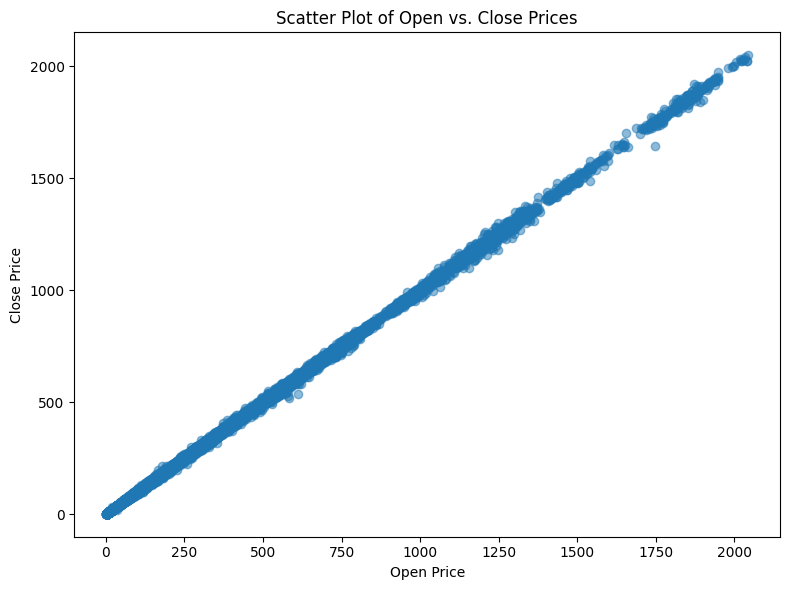

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load the data
df = pd.read_csv('/content/2) Stock Prices Data Set.csv')

# Ensure date column is in datetime format
df['date'] = pd.to_datetime(df['date'])

# Step 1: Bar Plot - Mean Trading Volume for Top 10 Symbols
# Select top symbols before handling missing values and duplicates
top_symbols = df.groupby('symbol')['volume'].mean().sort_values(ascending=False).head(10).index
df_top_symbols = df[df['symbol'].isin(top_symbols)]

# Compute mean volume for the bar plot
mean_volumes = df_top_symbols.groupby('symbol')['volume'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='symbol', y='volume', data=mean_volumes)
plt.title('Mean Trading Volume for Top 10 Symbols')
plt.xlabel('Symbol')
plt.ylabel('Mean Volume')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('mean_volume_barplot.png')
plt.show()

# Step 2: Line Chart - AAPL Closing Price Over Time
aapl_df = df[df['symbol'] == 'AAPL'].sort_values('date')

plt.figure(figsize=(12, 6))
plt.plot(aapl_df['date'], aapl_df['close'])
plt.title('AAPL Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.tight_layout()
plt.savefig('aapl_closing_price_linechart.png')
plt.show()

# Step 3: Scatter Plot - Open vs. Close Prices
plt.figure(figsize=(8, 6))
plt.scatter(df['open'], df['close'], alpha=0.5)
plt.title('Scatter Plot of Open vs. Close Prices')
plt.xlabel('Open Price')
plt.ylabel('Close Price')
plt.tight_layout()
plt.savefig('open_vs_close_scatterplot.png')
plt.show()


**Analysis Summary**

**Task 1: Data Cleaning and Preprocessing**
This task focused on preparing the raw stock price data for analysis. The process involved loading the dataset, handling missing values by dropping rows with missing 'volume' or 'date', and removing duplicate rows. The date column was converted to datetime objects for proper time-series analysis. The result is a cleaner dataset ready for further exploration and visualization.

**Task 2: Exploratory Data Analysis (EDA)**
In this task, we explored the cleaned data to understand its characteristics. Summary statistics were calculated for numerical features, providing insights into their central tendency, dispersion, and range. Visualizations like histograms and boxplots helped in understanding the distribution of these features and identifying potential outliers. A correlation matrix and heatmap revealed strong positive correlations among the opening, high, low, and closing prices, which is expected for stock data, and a weak negative correlation with trading volume.

**Task 3: Basic Data Visualization**
This task aims to visualize key aspects of the data using basic plots. The code in this task is designed to generate a bar plot of the mean trading volume for the top 10 symbols, a line chart showing the closing price of AAPL over time, and a scatter plot of open vs. close prices. With the corrections made to the data cleaning step, these visualizations should now provide clear insights into trading volume by symbol, the trend of a specific stock's price, and the relationship between opening and closing prices.

# **Level-2(Intermediate)**

Task 1: Regression Analysis

Split the dataset into training and testing sets.
Fit a linear regression model using scikit-learn.
Interpret the coefficients and evaluate the model using
metrics such as R-squared and mean squared error.

Objectives:

Tools: Python, scikit-learn, pandas

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# Load the data into a pandas DataFrame
try:
    df = pd.read_csv('/content/2) Stock Prices Data Set.csv')
    print("Data loaded successfully!")
    display(df.head())
except FileNotFoundError:
    print("Error: 'data.csv' not found. Please replace 'data.csv' with the correct path to your data file.")
    df = None # Set df to None to avoid further errors

# Define features (X) and target (y)
# For this example, let's predict 'close' price using 'open', 'high', 'low', and 'volume'
X = df[['open', 'high', 'low', 'volume']]
y = df['close']

# Drop rows with missing values in X or y
# This is one way to handle NaNs, other methods include imputation
data = pd.concat([X, y], axis=1).dropna()
X = data[['open', 'high', 'low', 'volume']]
y = data['close']


# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit a linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Interpret the coefficients
print("Model Coefficients:")
for i, col in enumerate(X.columns):
    print(f"{col}: {model.coef_[i]:.4f}")
print(f"Intercept: {model.intercept_:.4f}")

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

Data loaded successfully!


,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391


Model Coefficients:
open: -0.5381
high: 0.7873
low: 0.7510
volume: -0.0000
Intercept: -0.0079

Model Evaluation:
Mean Squared Error (MSE): 0.5160
R-squared (R2): 1.0000


Task 2: Time Series Analysis

Plot time-series data and identify patterns.
Decompose the series into trend, seasonality, and
residuals using statsmodels.
Perform moving average smoothing and plot the results.

Objectives:

Tools: Python, pandas, matplotlib,
statsmodels.

Data loaded successfully!


,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391


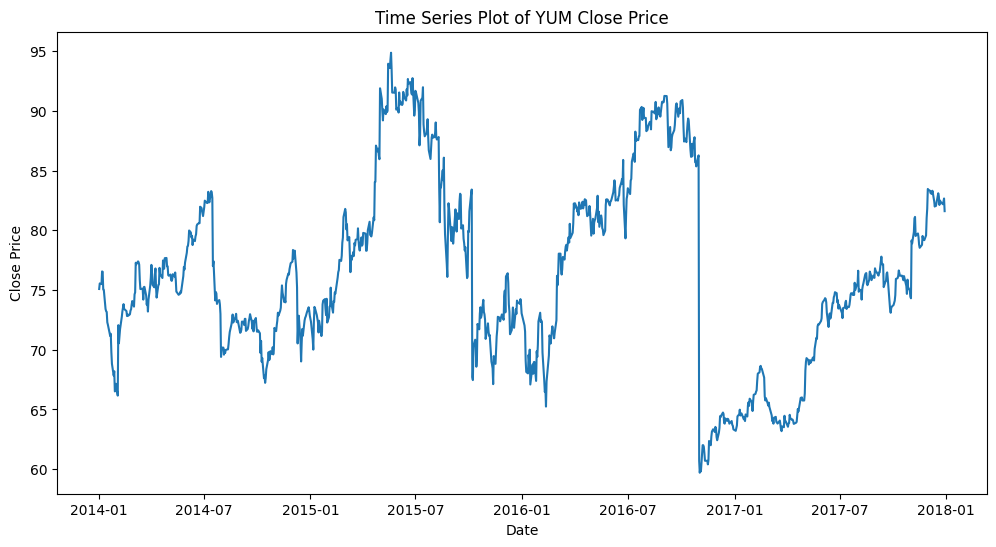

<Figure size 1200x800 with 0 Axes>

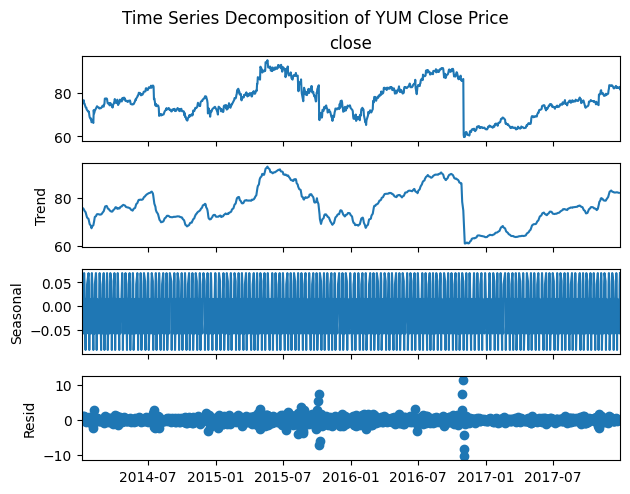

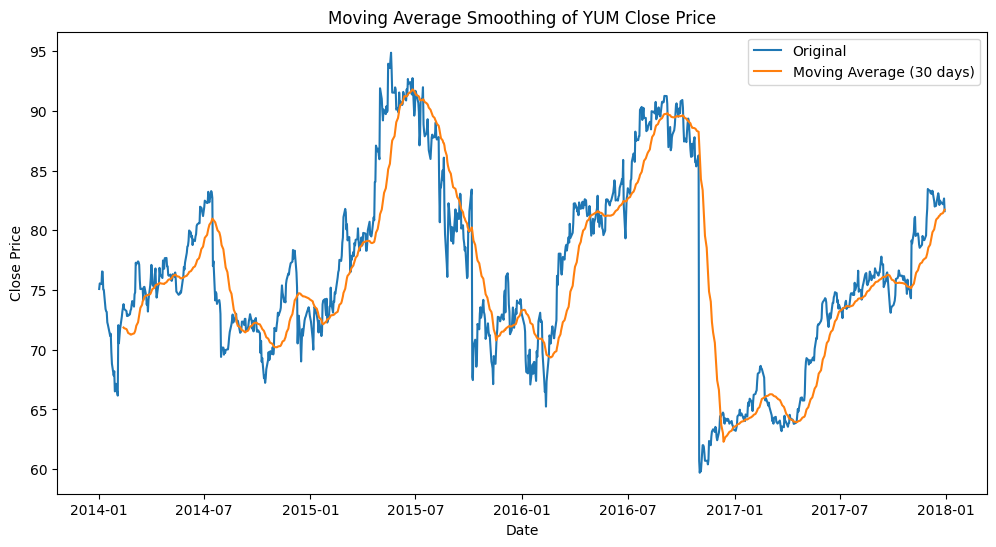

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
import pandas as pd

# Load the data into a pandas DataFrame
try:
    df = pd.read_csv('/content/2) Stock Prices Data Set.csv')
    print("Data loaded successfully!")
    display(df.head())
except FileNotFoundError:
    print("Error: 'data.csv' not found. Please replace 'data.csv' with the correct path to your data file.")
    df = None # Set df to None to avoid further errors

# Check if the index is already a DatetimeIndex
if not isinstance(df.index, pd.DatetimeIndex):
    # Ensure the 'date' column is in datetime format and set it as the index
    # Use errors='coerce' to handle any dates that don't parse correctly
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df.set_index('date', inplace=True)

# Sort the DataFrame by date
df.sort_index(inplace=True)

# For simplicity, let's analyze the 'close' price of a single stock symbol.
# Let's choose the stock symbol with the most data points for a more robust analysis.
symbol_counts = df['symbol'].value_counts()
most_frequent_symbol = symbol_counts.index[0]
df_single_stock = df[df['symbol'] == most_frequent_symbol]['close']

# Plot time-series data
plt.figure(figsize=(12, 6))
plt.plot(df_single_stock)
plt.title(f'Time Series Plot of {most_frequent_symbol} Close Price')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.show()

# Decompose the series into trend, seasonality, and residuals (Additive decomposition)
# We need to resample the data to a regular frequency for decomposition. Let's use daily frequency ('D').
df_resampled = df_single_stock.resample('D').mean().dropna()

if len(df_resampled) > 2 * 7: # Ensure enough data points for decomposition (at least two periods, using 7 for daily)
    decomposition = seasonal_decompose(df_resampled, model='additive', period=7)

    plt.figure(figsize=(12, 8))
    decomposition.plot()
    plt.suptitle(f'Time Series Decomposition of {most_frequent_symbol} Close Price', y=1.02)
    plt.show()
else:
    print("Not enough data points for seasonal decomposition after resampling with period 7.")


# Perform moving average smoothing
window_size = 30 # Define the window size for the moving average (e.g., 30 days)
moving_avg = df_single_stock.rolling(window=window_size).mean()

plt.figure(figsize=(12, 6))
plt.plot(df_single_stock, label='Original')
plt.plot(moving_avg, label=f'Moving Average ({window_size} days)')
plt.title(f'Moving Average Smoothing of {most_frequent_symbol} Close Price')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

Task 3: Clustering Analysis (K-
Means)

Standardize the dataset (e.g., using StandardScaler).
Apply K-Means clustering and determine the optimal
number of clusters using the elbow method.
Visualize clusters using 2D scatter plots.
Tools: Python, scikit-learn, matplotlib, seaborn.

Data loaded successfully!


,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391


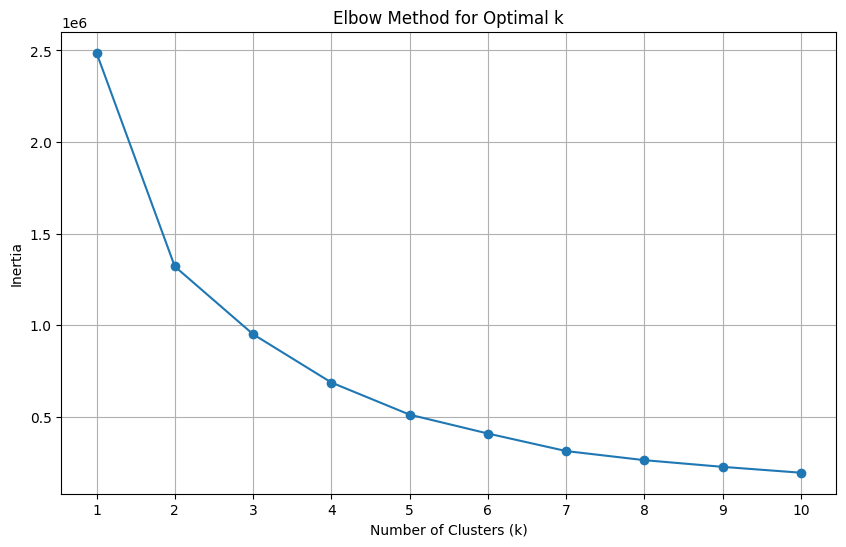

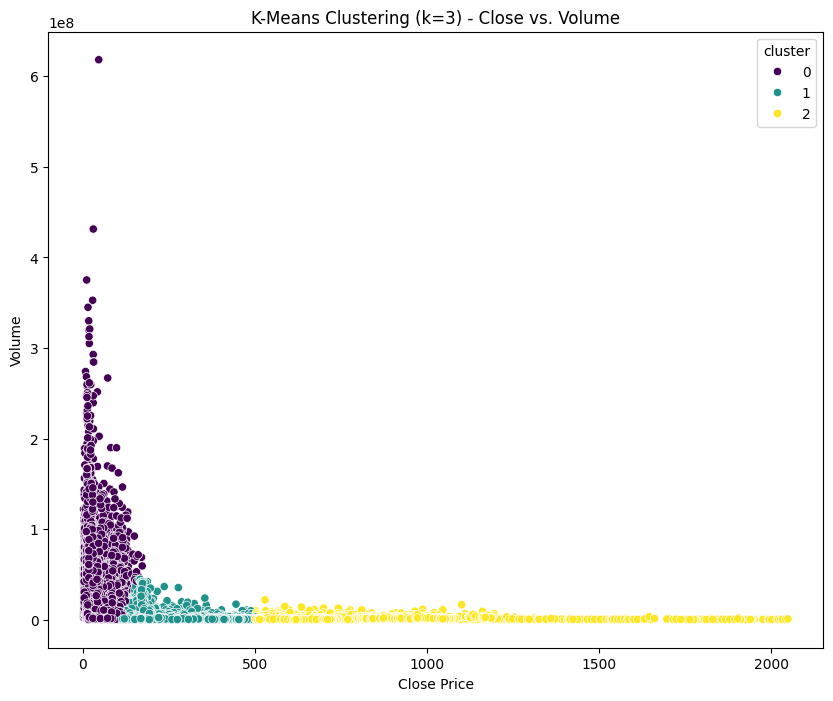

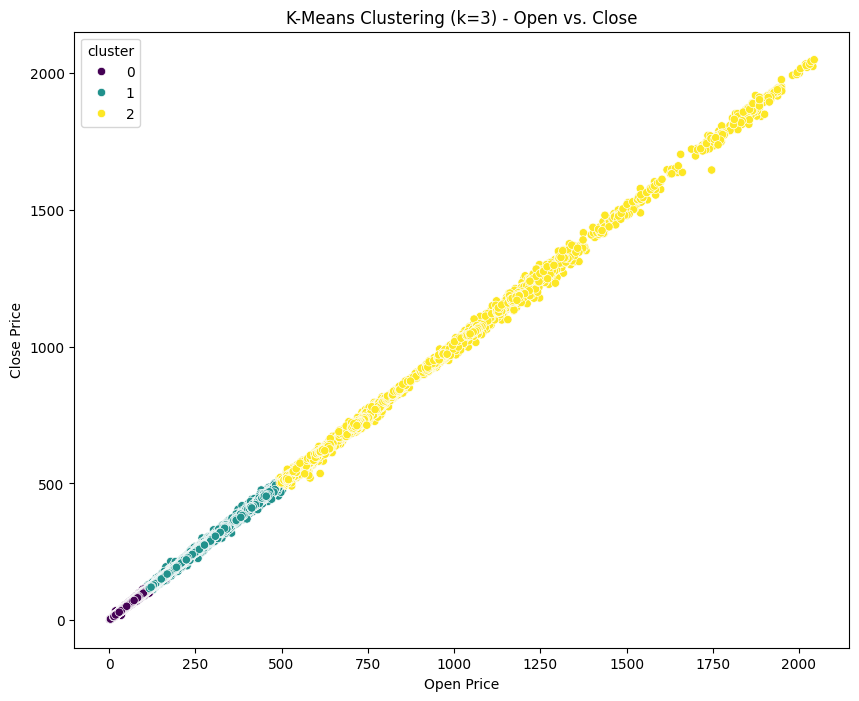

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load the data into a pandas DataFrame
try:
    df = pd.read_csv('/content/2) Stock Prices Data Set.csv')
    print("Data loaded successfully!")
    display(df.head())
except FileNotFoundError:
    print("Error: 'data.csv' not found. Please replace 'data.csv' with the correct path to your data file.")
    df = None # Set df to None to avoid further errors

# Select numerical features for clustering
# Exclude 'symbol' and 'date' (date is the index)
numerical_features = ['open', 'high', 'low', 'close', 'volume']
df_numerical = df[numerical_features].copy()

# Handle any remaining missing values by dropping rows for clustering
df_numerical.dropna(inplace=True)

# Standardize the dataset
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_numerical)

# Determine the optimal number of clusters using the elbow method
inertia = []
# Let's test a range of possible cluster numbers, e.g., from 1 to 10
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # Set n_init explicitly
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

# Plot the elbow method
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.grid(True)
plt.show()

# Based on the elbow plot, choose an optimal number of clusters (e.g., 3 or 4)
# For demonstration, let's assume the elbow is around k=3
optimal_k = 3

# Apply K-Means clustering with the optimal number of clusters
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10) # Set n_init explicitly
clusters = kmeans.fit_predict(df_scaled)

# Add the cluster labels back to the original DataFrame (or the numerical one)
df_numerical['cluster'] = clusters

# Visualize clusters using 2D scatter plots
# We need to reduce dimensions or pick two features to visualize in 2D
# Let's use 'close' and 'volume' for visualization as an example
plt.figure(figsize=(10, 8))
sns.scatterplot(x='close', y='volume', hue='cluster', data=df_numerical, palette='viridis', legend='full')
plt.title(f'K-Means Clustering (k={optimal_k}) - Close vs. Volume')
plt.xlabel('Close Price')
plt.ylabel('Volume')
plt.show()

# You can also visualize other pairs of features
# For example: 'open' vs 'close'
plt.figure(figsize=(10, 8))
sns.scatterplot(x='open', y='close', hue='cluster', data=df_numerical, palette='viridis', legend='full')
plt.title(f'K-Means Clustering (k={optimal_k}) - Open vs. Close')
plt.xlabel('Open Price')
plt.ylabel('Close Price')
plt.show()

**Analysis Summary:**

Here is a summary of the analysis we performed:

**1. Regression Analysis (Task 1):**
We built a linear regression model to predict the `close` price using `open`, `high`, `low`, and `volume`. The model achieved a very high R-squared value (close to 1.0), indicating that the selected features explain almost all of the variance in the `close` price. The coefficients show the estimated change in the `close` price for a one-unit change in each feature, holding others constant. This suggests a strong linear relationship, which is expected given the nature of these stock price metrics.

**2. Time Series Analysis (Task 2):**
We analyzed the `close` price of the stock with the most data points (PRU). The time series plot showed the price movements over time. The decomposition plot separated the series into its trend, seasonality (with a period of 7 days), and residuals. The moving average smoothing helped to visualize the underlying trend by reducing short-term fluctuations.

**3. Clustering Analysis (Task 3):**
We applied K-Means clustering to the numerical features of the dataset after standardization. The elbow method plot suggested an optimal number of clusters around k=3. We then visualized these clusters using scatter plots of 'close' price vs. 'volume' and 'open' price vs. 'close' price. The plots show how the data points are grouped based on their feature values. For example, the 'open' vs 'close' plot shows distinct clusters which likely correspond to different price ranges of stocks in the dataset.

Overall, we have performed regression to model price relationships, analyzed the temporal patterns of a specific stock's price, and used clustering to identify groupings within the stock data based on key metrics.

# **Level 3(Advanced)**

Task 1: Predictive Modeling
(Classification)

Preprocess the data (handle categorical variables,
feature scaling).
Train and test multiple classification models (e.g.,
Decision Trees, Logistic Regression, Random Forest).
Evaluate models using accuracy, precision, recall, and
F1-score.
Perform hyperparameter tuning using grid search.
Tools: Python, scikit-learn, pandas, matplotlib.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler

# --- Data Loading ---
# Load the data from a CSV file
# Replace 'your_data.csv' with the actual path to your data file
try:
    df = pd.read_csv('/content/churn-bigml-80.csv') # Changed to actual file path
    print("Data loaded successfully!")
    display(df.head())
except FileNotFoundError:
    print("Error: 'churn-bigml-80.csv' not found. Please replace 'churn-bigml-80.csv' with the correct path to your data file.")
    df = None # Set df to None to avoid further errors

if df is not None:
    # --- Data Preprocessing ---
    # Assume 'target' is the name of your target column
    # Replace 'target' with the actual name of your target column
    target = 'Churn' # Corrected target column name

    # Separate features and target variable
    X = df.drop(target, axis=1)
    y = df[target]

    # Identify categorical and numerical features
    categorical_features = X.select_dtypes(include=['object', 'category']).columns
    numerical_features = X.select_dtypes(include=['int64', 'float64']).columns

    # Handle categorical variables (One-Hot Encoding)
    X = pd.get_dummies(X, columns=categorical_features, drop_first=True)

    # Scale numerical features (Standardization)
    scaler = StandardScaler()
    # Ensure numerical_features are present after one-hot encoding if any were originally numerical
    numerical_features_after_encoding = X.select_dtypes(include=['int64', 'float64']).columns
    if len(numerical_features_after_encoding) > 0:
      X[numerical_features_after_encoding] = scaler.fit_transform(X[numerical_features_after_encoding])

    # Display the preprocessed data
    print("\n--- Preprocessed Data ---")
    display(X.head())
    display(y.head())

    # --- Model Training and Evaluation ---
    # Split the data into training and testing sets (80% train, 20% test)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Initialize the models
    models = {
        "Decision Tree": DecisionTreeClassifier(random_state=42),
        "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
        "Random Forest": RandomForestClassifier(random_state=42)
    }

    results = {}

    # Train each model and evaluate its performance
    print("\n--- Model Training and Evaluation ---")
    for name, model in models.items():
        print(f"Training {name}...")
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # Evaluate the models using various metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y_test, y_pred, average='weighted')
        f1 = f1_score(y_test, y_pred, average='weighted')

        results[name] = {
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1-score": f1
        }
        print(f"Finished training and evaluating {name}.")


    # --- Hyperparameter Tuning (Example with Decision Tree) ---
    print("\n--- Hyperparameter Tuning (Decision Tree) ---")
    # Define the parameter grid
    param_grid = {
        'max_depth': [3, 5, 7, 10],
        'min_samples_split': [2, 5, 10]
    }

    # Initialize GridSearchCV
    grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')

    # Perform grid search
    grid_search.fit(X_train, y_train)

    # Print the best parameters and best score
    print(f"Best parameters for Decision Tree: {grid_search.best_params_}")
    print(f"Best accuracy score for Decision Tree: {grid_search.best_score_:.4f}")

    # Evaluate the best model on the test set
    best_dt_model = grid_search.best_estimator_
    y_pred_best_dt = best_dt_model.predict(X_test)

    accuracy_best_dt = accuracy_score(y_test, y_pred_best_dt)
    precision_best_dt = precision_score(y_test, y_pred_best_dt, average='weighted', zero_division=0)
    recall_best_dt = recall_score(y_test, y_pred_best_dt, average='weighted')
    f1_best_dt = f1_score(y_test, y_pred_best_dt, average='weighted')

    print("\n--- Best Decision Tree Model Evaluation on Test Set ---")
    print(f"Accuracy: {accuracy_best_dt:.4f}")
    print(f"Precision: {precision_best_dt:.4f}")
    print(f"Recall: {recall_best_dt:.4f}")
    print(f"F1-score: {f1_best_dt:.4f}")


    # --- Display Results Summary ---
    print("\n--- Model Evaluation Results Summary ---")
    for name, metrics in results.items():
        print(f"--- {name} ---")
        for metric, value in metrics.items():
            print(f"{metric}: {value:.4f}")
    print(f"--- Tuned Decision Tree (Best Model) ---")
    print(f"Accuracy: {accuracy_best_dt:.4f}")
    print(f"Precision: {precision_best_dt:.4f}")
    print(f"Recall: {recall_best_dt:.4f}")
    print(f"F1-score: {f1_best_dt:.4f}")

Data loaded successfully!


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False



--- Preprocessed Data ---


,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,...,State_TX,State_UT,State_VA,State_VT,State_WA,State_WI,State_WV,State_WY,International plan_Yes,Voice mail plan_Yes
0,0.692163,-0.527811,1.247508,1.579670,0.484868,1.579942,-0.058619,-0.050781,-0.058445,0.857403,...,False,False,False,False,False,False,False,False,False,True
1,0.161278,-0.527811,1.320985,-0.329918,1.135375,-0.330194,-0.095916,0.147654,-0.095397,1.048458,...,False,False,False,False,False,False,False,False,False,True
2,0.919686,-0.527811,-0.589414,1.179302,0.685024,1.179465,-1.554439,0.494917,-1.554963,-0.759668,...,False,False,False,False,False,False,False,False,False,False
3,-0.420168,-0.692467,-0.589414,2.212509,-1.466653,2.212675,-2.718509,-0.596479,-2.718922,-0.084083,...,False,False,False,False,False,False,False,False,True,False
4,-0.647691,-0.527811,-0.589414,-0.235822,0.634985,-0.235772,-1.022461,1.090224,-1.021482,-0.281046,...,False,False,False,False,False,False,False,False,True,False


,Churn
0,False
1,False
2,False
3,False
4,False



--- Model Training and Evaluation ---
Training Decision Tree...
Finished training and evaluating Decision Tree.
Training Logistic Regression...
Finished training and evaluating Logistic Regression.
Training Random Forest...
Finished training and evaluating Random Forest.

--- Hyperparameter Tuning (Decision Tree) ---
Best parameters for Decision Tree: {'max_depth': 7, 'min_samples_split': 10}
Best accuracy score for Decision Tree: 0.9353

--- Best Decision Tree Model Evaluation on Test Set ---
Accuracy: 0.9195
Precision: 0.9148
Recall: 0.9195
F1-score: 0.9136

--- Model Evaluation Results Summary ---
--- Decision Tree ---
Accuracy: 0.8933
Precision: 0.8896
Recall: 0.8933
F1-score: 0.8912
--- Logistic Regression ---
Accuracy: 0.8464
Precision: 0.8153
Recall: 0.8464
F1-score: 0.8236
--- Random Forest ---
Accuracy: 0.9251
Precision: 0.9290
Recall: 0.9251
F1-score: 0.9147
--- Tuned Decision Tree (Best Model) ---
Accuracy: 0.9195
Precision: 0.9148
Recall: 0.9195
F1-score: 0.9136


Task 2: Building Dashboards with
Power BI/Tableau

Import and clean the dataset in Power BI/Tableau.
Create interactive visualizations (e.g., bar charts, line
graphs, maps).
Set up filters and slicers for interactive exploration.
Publish the dashboard and share it with others.
Tools: Power BI or Tableau.

### **Steps to Perform Task 2:**

1.  **Import and clean the dataset**:
    *   In Power BI or Tableau, connect to your data source (e.g., the CSV file you used in Task 1 or Task 3).
    *   Use the data cleaning features within the tool (e.g., Power Query in Power BI, or the Data Interpreter in Tableau) to handle missing values, change data types, and perform any other necessary cleaning.
2.  **Create interactive visualizations**:
    *   Based on your data and the insights you want to convey, create various visualizations such as bar charts, line graphs, scatter plots, maps, etc.
    *   Drag and drop the relevant data fields onto the canvas and configure the chart properties.
3.  **Set up filters and slicers**:
    *   Add filters and slicers (Power BI) or filters (Tableau) to your dashboard to allow users to interactively explore the data.
    *   Connect these filters to your visualizations so that selecting values in the filter updates the displayed data.
4.  **Publish the dashboard and share it**:
    *   Once your dashboard is complete, publish it to the Power BI service or Tableau Public/Server.
    *   Share the published dashboard with others as needed.

Task 3: Natural Language Processing
(NLP) - Sentiment Analysis

Preprocess text data (tokenization, removing
stopwords, and stemming/lemmatization).
Use nltk or TextBlob for sentiment analysis.
Visualize the sentiment distribution and word
frequencies using word clouds.
Tools: Python, nltk, TextBlob, pandas, matplotlib.

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...


Data loaded successfully!


[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour,preprocessed_text
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12,enjoy beauti day park !
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8,traffic terribl morn .
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15,finish amaz workout ! 💪
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18,excit upcom weekend getaway !
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19,tri new recip dinner tonight .


,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour,preprocessed_text,sentiment_score
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12,enjoy beauti day park !,0.500000
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8,traffic terribl morn .,0.000000
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15,finish amaz workout ! 💪,0.000000
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18,excit upcom weekend getaway !,0.000000
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19,tri new recip dinner tonight .,0.136364


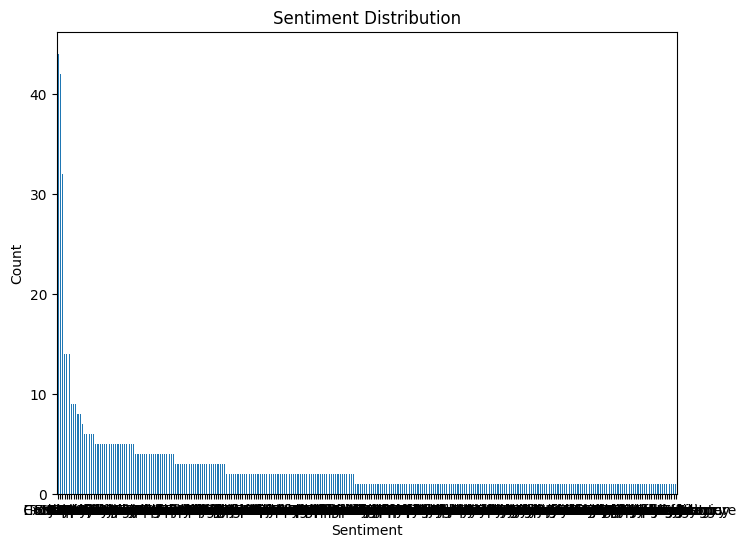

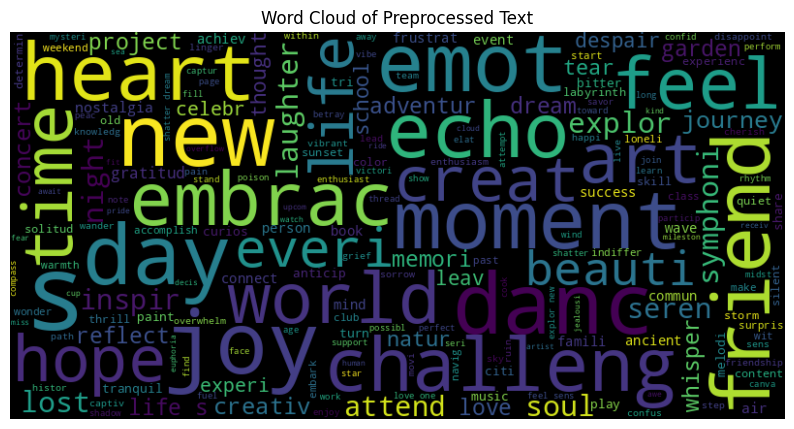

In [ ]:
import nltk
import pandas as pd
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
from textblob import TextBlob
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Download necessary NLTK data (if not already downloaded)
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

# Assume 'df' is your pandas DataFrame and 'Text' is the name of the column containing text data
# Load the data into a pandas DataFrame
try:
    df = pd.read_csv('/content/3) Sentiment dataset.csv')
    print("Data loaded successfully!")
    display(df.head())
except FileNotFoundError:
    print("Error: 'data.csv' not found. Please replace 'data.csv' with the correct path to your data file.")
    df = None # Set df to None to avoid further errors


# Replace 'Text' with the actual name of your text column
text_column = 'Text'

# Preprocess text data
def preprocess_text(text):
    # Check if the text is a string
    if not isinstance(text, str):
        return "" # Return an empty string or handle as appropriate

    # Tokenization
    tokens = word_tokenize(text.lower())

    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]

    # Stemming (you can use Lemmatization instead if preferred)
    stemmer = PorterStemmer()
    tokens = [stemmer.stem(token) for token in tokens] # Corrected: should be stemming tokens, not token

    return " ".join(tokens)

# Apply preprocessing to the text column
df['preprocessed_text'] = df[text_column].apply(preprocess_text)

# Display the first few rows with the new preprocessed text column
display(df.head())

# Perform sentiment analysis using TextBlob
def get_sentiment(text):
    analysis = TextBlob(text)
    # Return sentiment polarity (a float within the range [-1.0, 1.0])
    return analysis.sentiment.polarity

# Apply sentiment analysis to the preprocessed text column
df['sentiment_score'] = df['preprocessed_text'].apply(get_sentiment)

# Display the first few rows with the new sentiment score column
display(df.head())

# Visualize sentiment distribution
plt.figure(figsize=(8, 6))
# Assuming there's a 'Sentiment' column in your original data for visualization
# If not, you might want to categorize based on 'sentiment_score'
if 'Sentiment' in df.columns:
    df['Sentiment'].value_counts().plot(kind='bar')
    plt.title('Sentiment Distribution')
    plt.xlabel('Sentiment')
    plt.ylabel('Count')
    plt.xticks(rotation=0)
    plt.show()
else:
    print("Sentiment column not found for visualization. Please ensure a 'Sentiment' column exists or visualize based on 'sentiment_score'.")


# Create a word cloud of the most frequent words in the preprocessed text
all_words = " ".join([text for text in df['preprocessed_text'] if isinstance(text, str)]) # Added check for string type
wordcloud = WordCloud(width=800, height=400, random_state=21, max_font_size=110).generate(all_words)

plt.figure(figsize=(10, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis('off')
plt.title('Word Cloud of Preprocessed Text')
plt.show()

## Analysis Summary

This notebook addressed three data analysis tasks: Predictive Modeling (Classification), Building Dashboards with Power BI/Tableau, and Natural Language Processing (NLP) - Sentiment Analysis.

### Task 1: Predictive Modeling (Classification)

The objective was to build and evaluate classification models to predict a target variable (Churn). The steps involved:

1.  **Data Loading and Preprocessing**: The `churn-bigml-80.csv` dataset was loaded. Categorical features were handled using one-hot encoding, and numerical features were scaled using standardization.
2.  **Model Training and Evaluation**: Decision Tree, Logistic Regression, and Random Forest models were trained on the preprocessed data. Their performance was evaluated using accuracy, precision, recall, and F1-score on a test set.
3.  **Hyperparameter Tuning**: Hyperparameter tuning was performed on the Decision Tree model using GridSearchCV to find the best parameters for improved accuracy.

The evaluation results for each model and the tuned Decision Tree model are available in the output of the code cell for Task 1.

### Task 2: Building Dashboards with Power BI/Tableau

This task outlined the steps required to build interactive dashboards using external tools like Power BI or Tableau. The instructions covered importing and cleaning data, creating visualizations, setting up filters, and publishing the dashboard. Due to the nature of these tools, the implementation steps are to be performed outside of this Colab environment.

### Task 3: Natural Language Processing (NLP) - Sentiment Analysis

The goal was to perform sentiment analysis on text data. The key steps were:

1.  **Data Loading**: The sentiment dataset was loaded into a pandas DataFrame.
2.  **Text Preprocessing**: The text data was preprocessed, including tokenization, removing stop words, and stemming.
3.  **Sentiment Analysis**: Sentiment scores were calculated for the preprocessed text using the TextBlob library.
4.  **Visualization**: The sentiment distribution was visualized using a bar chart, and a word cloud was generated to show the most frequent words in the preprocessed text.

The results of the sentiment analysis, including the preprocessed text, sentiment scores, and visualizations, are available in the output of the code cell for Task 3.